# Gradient Descent: The Role of Learning Rates

This notebook investigates how the **step size** (learning rate) $\alpha$ affects the convergence of gradient descent. We visualize trajectories on quadratic and exponential-quadratic objectives with different condition numbers and learning rates. The learning objectives are:

- Understand the theoretical step-size bound $\alpha < 2/L$ for $L$-smooth functions.
- See firsthand the trade-off between slow convergence (step size too small) and overshooting / divergence (step size too large).
- Observe that the optimal step size $\alpha^* \approx 2/(\lambda_{\min} + \lambda_{\max})$ scales as $\approx 2/\lambda_{\max}$ when $\lambda_{\max} \gg \lambda_{\min}$.

## Step-Size Theory for Smooth Functions

Consider minimizing an $L$-smooth function $f$ (i.e., $\|\nabla f(x) - \nabla f(y)\| \leq L\|x - y\|$ for all $x, y$). Gradient descent with constant step size $\alpha$ satisfies

$$
f(x^{k+1}) \leq f(x^k) - \alpha\Bigl(1 - \frac{\alpha L}{2}\Bigr)\|\nabla f(x^k)\|^2.
$$

For this to guarantee descent at every step, we need $\alpha < 2/L$. The optimal constant step size is $\alpha^* = 1/L$, which gives the tightest per-step improvement.

**Trade-off:**
- **Too small** $\alpha$: each step makes tiny progress and convergence is slow.
- **Too large** $\alpha$: the iterates overshoot the minimum and may diverge.

We illustrate this below on an exponential-quadratic function $f(x,y) = \exp\!\bigl(\tfrac{1}{2}(x^2 + c\,y^2)\bigr)$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the exponential of the quadratic function (2D case)
def exp_quadratic(x, y):
    return np.exp(0.5 * (x**2 + 10 * y**2))

# Define the gradient of exp_quadratic (optional, for gradient descent)
def exp_quadratic_gradient(x, y):
    df_dx = x * np.exp(0.5 * (x**2 + 10 * y**2))
    df_dy = 10 * y * np.exp(0.5 * (x**2 + 10 * y**2))
    return np.array([df_dx, df_dy])

# Visualization of the exponential of quadratic function (2D)
def plot_exp_quadratic():
    # Create a grid of points for contour plot
    x = np.linspace(-2, 2, 400)
    y = np.linspace(-2, 2, 400)
    X, Y = np.meshgrid(x, y)
    Z = exp_quadratic(X, Y)

    # Plot the surface and contours of exp_quadratic
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
    ax.set_title("Exponential of Quadratic Function (2D)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("exp(f(x, y))")
    plt.show()

# Call the function to visualize the 2D exponential of quadratic
plot_exp_quadratic()

## Gradient Descent Trajectories with Different Learning Rates

Below we run gradient descent on $f(x,y) = \exp\!\bigl(\tfrac{1}{2}(x^2 + 2y^2)\bigr)$ starting from $(-1.5, 1.5)$ with three learning rates. Observe how larger learning rates take bigger initial steps but may oscillate, while smaller rates progress steadily but slowly.

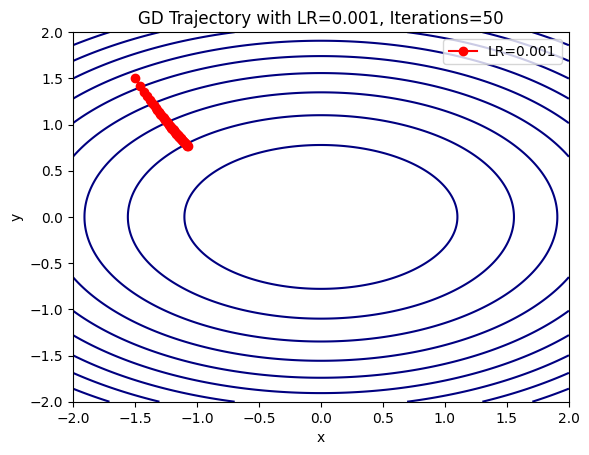

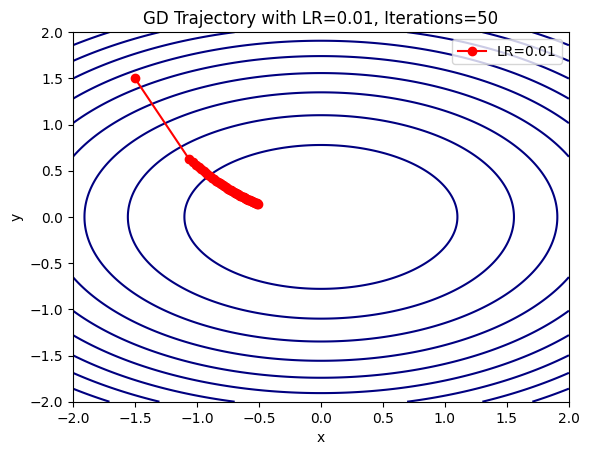

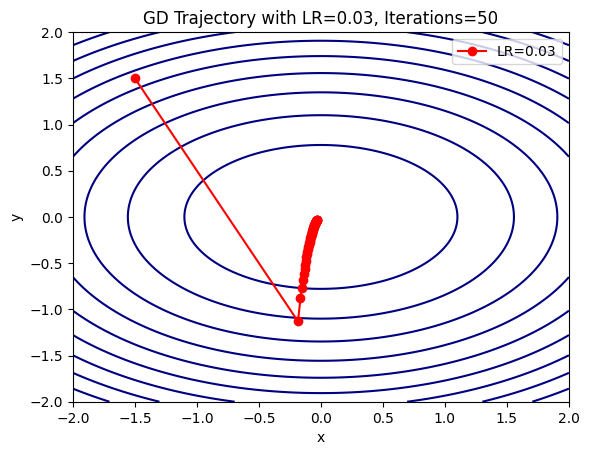

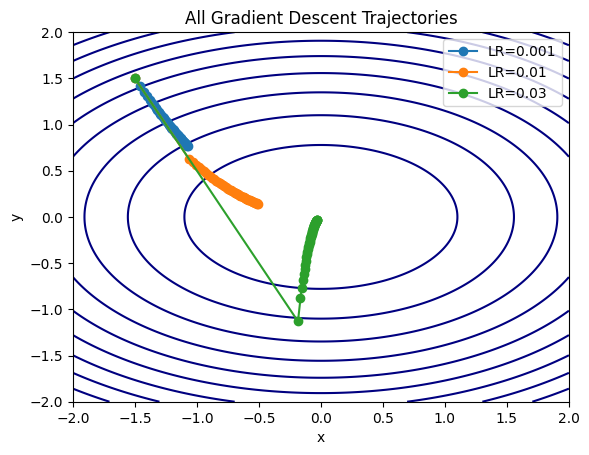

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the exponential of the quadratic function (2D case)
def exp_quadratic(x, y):
    return np.exp(0.5 * (x**2 + 2 * y**2))

# Define the gradient of exp_quadratic for gradient descent
def exp_quadratic_gradient(x, y):
    df_dx = x * np.exp(0.5 * (x**2 + 2 * y**2))
    df_dy = 2 * y * np.exp(0.5 * (x**2 + 2 * y**2))
    return np.array([df_dx, df_dy])

# Gradient Descent Implementation for 2D functions
def gradient_descent_2d(grad_func, initial_point, learning_rate, num_iterations):
    points = [initial_point]
    x, y = initial_point
    for _ in range(num_iterations):
        grad = grad_func(x, y)
        x = x - learning_rate * grad[0]
        y = y - learning_rate * grad[1]
        points.append([x, y])
    return np.array(points)

# Visualization: Plot Contours and Trajectories
def plot_contour_with_trajectory(points, learning_rate, num_iterations, label):
    # Create a grid of points for contour plot
    x = np.linspace(-2, 2, 400)
    y = np.linspace(-2, 2, 400)
    X, Y = np.meshgrid(x, y)
    Z = exp_quadratic(X, Y)

    # Plot the contour of the exponential of quadratic function
    plt.contour(X, Y, Z, levels=np.logspace(0, 5, 20), cmap='jet')

    # Plot the gradient descent trajectory
    plt.plot(points[:, 0], points[:, 1], 'o-', label=label, color='red')
    plt.title(f"GD Trajectory with LR={learning_rate}, Iterations={num_iterations}")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()

# Visualization of all trajectories in one plot
def plot_all_trajectories(trajectories, learning_rates):
    # Create a grid of points for contour plot
    x = np.linspace(-2, 2, 400)
    y = np.linspace(-2, 2, 400)
    X, Y = np.meshgrid(x, y)
    Z = exp_quadratic(X, Y)

    # Plot the contour of the exponential of quadratic function
    plt.contour(X, Y, Z, levels=np.logspace(0, 5, 20), cmap='jet')

    # Plot all trajectories in one figure
    for i, points in enumerate(trajectories):
        plt.plot(points[:, 0], points[:, 1], 'o-', label=f"LR={learning_rates[i]}")

    plt.title("All Gradient Descent Trajectories")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()

# Set up initial conditions and parameters
initial_point = np.array([-1.5, 1.5])  # Starting point
num_iterations = 50  # Number of iterations

# Run gradient descent for different learning rates
learning_rates = [0.001, 0.01, 0.03]
trajectories = []

for lr in learning_rates:
    points = gradient_descent_2d(exp_quadratic_gradient, initial_point, lr, num_iterations)
    trajectories.append(points)
    plot_contour_with_trajectory(points, lr, num_iterations, label=f"LR={lr}")

# Plot all trajectories in one figure
plot_all_trajectories(trajectories, learning_rates)


## Effect of Curvature: Quadratic Functions with Varying Eigenvalues

Now we study pure quadratics $f(z) = \tfrac{1}{2}z^\top A\,z$ where $A = Q\Lambda Q^\top$ has eigenvalues $\lambda_{\min}$ and $\lambda_{\max}$. We vary the eigenvalue ratio (condition number $\kappa = \lambda_{\max}/\lambda_{\min}$) and the learning rate to observe:

- For each $\kappa$, there is a maximum stable step size $\alpha_{\max} \approx 2/\lambda_{\max}$.
- As $\kappa$ increases, the range of "good" learning rates shrinks and GD trajectories zig-zag more.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the quadratic function with matrix A
def quadratic(z, A):
    return 0.5 * z.T @ A @ z

# Define the gradient of the quadratic function
def quadratic_gradient(z, A):
    return A @ z

# Gradient Descent Implementation for 2D quadratic function
def gradient_descent_2d(grad_func, initial_point, A, learning_rate, num_iterations):
    points = [initial_point]
    z = initial_point
    for _ in range(num_iterations):
        grad = grad_func(z, A)
        z = z - learning_rate * grad
        points.append(z)
    return np.array(points)

# Filter points to only keep those within a desired region
def filter_points(points, x_min, x_max, y_min, y_max):
    filtered = [point for point in points if x_min <= point[0] <= x_max and y_min <= point[1] <= y_max]
    return np.array(filtered) if len(filtered) > 0 else np.empty((0, 2))

# Visualization of the contour and trajectory within a desired region
def plot_contour_with_trajectory(points, learning_rate, A, num_iterations, label, x_min, x_max, y_min, y_max):
    # Create a grid of points for contour plot within the region
    x = np.linspace(x_min, x_max, 400)
    y = np.linspace(y_min, y_max, 400)
    X, Y = np.meshgrid(x, y)
    Z = 0.5 * (A[0, 0] * X**2 + 2 * A[0, 1] * X * Y + A[1, 1] * Y**2)

    # Plot the contour of the quadratic function
    plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='jet')

    # Filter the trajectory points to the desired region
    filtered_points = filter_points(points, x_min, x_max, y_min, y_max)

    # Check if there are any points to plot
    if len(filtered_points) > 0:
        # Plot the filtered gradient descent trajectory
        plt.plot(filtered_points[:, 0], filtered_points[:, 1], 'o-', label=label, color='red')
    else:
        print(f"No points in the region for learning rate {learning_rate}")

    plt.title(f"GD Trajectory with LR={learning_rate}, Iterations={num_iterations}")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.legend()
    plt.show()

# Generate symmetric positive definite matrix A
def generate_quadratic_matrix(smallest_eigenvalue, largest_eigenvalue, rotation_angle=0):
    # Eigenvalues determine the curvature
    Lambda = np.diag([smallest_eigenvalue, largest_eigenvalue])

    # Rotation matrix Q for rotation by rotation_angle
    c, s = np.cos(rotation_angle), np.sin(rotation_angle)
    Q = np.array([[c, -s], [s, c]])

    # Construct A = Q * Lambda * Q^T
    A = Q @ Lambda @ Q.T
    return A

# Initial point for gradient descent
initial_point = np.array([-10, 10])

# Number of iterations for gradient descent
num_iterations = 300

# Smallest and largest eigenvalues for different curvature
smallest_eigenvalue = 1
largest_eigenvalue_list = [5, 10, 50, 100]  # Different eigenvalue ratios to simulate different curvatures

# Define the desired region to plot
x_min, x_max = -8, 5
y_min, y_max = -8, 5


learning_rates = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]  # Try a grid of learning rates

# Iterate over the largest eigenvalues
for largest_eigenvalue in largest_eigenvalue_list:
    # Generate a quadratic matrix with different curvatures
    A = generate_quadratic_matrix(smallest_eigenvalue, largest_eigenvalue, rotation_angle=np.pi/6)

    # Iterate over learning rates
    for lr in learning_rates:
        points = gradient_descent_2d(quadratic_gradient, initial_point, A, lr, num_iterations)
        plot_contour_with_trajectory(points, lr, A, num_iterations, label=f"LR={lr}, Eig-Ratio={largest_eigenvalue/smallest_eigenvalue}",
                                     x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max)

## Empirical Verification: Optimal Step Size $\approx 2/\lambda_{\max}$

The theory for gradient descent on a quadratic $f(z) = \tfrac{1}{2}z^\top A\,z$ tells us that the optimal constant step size is

$$
\alpha^* = \frac{2}{\lambda_{\min} + \lambda_{\max}}.
$$

When $\lambda_{\max} \gg \lambda_{\min}$, this simplifies to $\alpha^* \approx 2/\lambda_{\max}$.

**Experiment design:** For a range of $\lambda_{\max}$ values (with $\lambda_{\min} = 1$ fixed), we search over a grid of step sizes and record the largest one for which GD converges within a tolerance. We then fit a linear regression of the optimal step size against $1/\lambda_{\max}$ and expect a slope close to $2$.

The largest learning rate for lambda_max = 50.0 is 0.03856666666666675
The largest learning rate for lambda_max = 7.758620689655173 is 0.2500629629629689
The largest learning rate for lambda_max = 4.205607476635515 is 0.4619592592592702
The largest learning rate for lambda_max = 2.8846153846153846 is 0.6745555555555716
The largest learning rate for lambda_max = 2.1951219512195124 is 0.8872518518517709
The largest learning rate for lambda_max = 1.7716535433070868 is 1.0989481481480479
The largest learning rate for lambda_max = 1.4851485148514851 is 1.3122444444443246
The largest learning rate for lambda_max = 1.278409090909091 is 1.5250407407406015
The largest learning rate for lambda_max = 1.1221945137157108 is 1.7382370370368783
The largest learning rate for lambda_max = 1.0 is 1.951233333333155


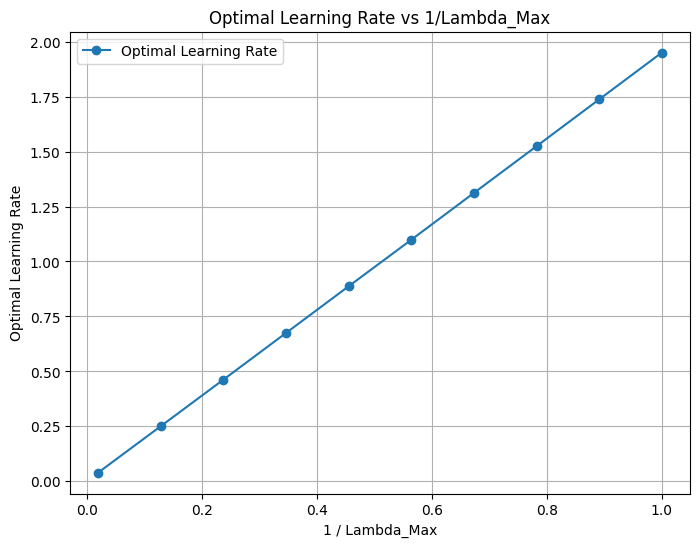

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression



# Define the quadratic function and its gradient
def quadratic(z, A):
    return 0.5 * z.T @ A @ z

def quadratic_gradient(z, A):
    return A @ z

# Gradient Descent Implementation
def gradient_descent(grad_func, A, initial_point, learning_rate, num_iterations):
    z = initial_point
    for _ in range(num_iterations):
        grad = grad_func(z, A)
        z = z - learning_rate * grad
    return z

# Function to find the optimal stepsize for a given lambda_max and dimension d
def find_optimal_stepsize(lambda_max, d, N=300, threshold=0.001):
    # Generate the eigenvalue matrix A
    Lambda = np.diag([1] + [lambda_max] * (d - 1))

    # Random orthogonal matrix Q for random rotation
    Q = np.linalg.qr(np.random.randn(d, d))[0]

    # Construct the quadratic matrix A = Q * Lambda * Q^T
    A = Q @ Lambda @ Q.T

    # Initialize random starting point
    initial_point = np.random.randn(d)

    # Search for the optimal stepsize from 1/(3 * lambda_max) to 2 / lambda_max
    learning_rate_min = 1 / (3 * lambda_max)
    learning_rate_max = 4 / lambda_max
    stepsizes = np.arange(learning_rate_min, learning_rate_max, 0.0001)

    optimal_stepsize = learning_rate_min
    success = False

    # Iterate over the range of stepsizes
    for stepsize in stepsizes:
        z_final = gradient_descent(quadratic_gradient, A, initial_point, stepsize, N)
        func_value = quadratic(z_final, A)

        if func_value < threshold:
            optimal_stepsize = stepsize
            success = True

    if success:
        print(f"The largest learning rate for lambda_max = {lambda_max} is {optimal_stepsize}")
    else:
        print(f"No successful learning rate found for lambda_max = {lambda_max}")

    return lambda_max, optimal_stepsize

# Run the function for a grid of lambda_max values and dimension d
def run_for_lambda_grid(lambda_max_values, d, N=100):
    results = []

    for lambda_max in lambda_max_values:
        lambda_max_val, optimal_stepsize = find_optimal_stepsize(lambda_max, d, N)
        results.append((lambda_max_val, optimal_stepsize))

    return results

# Plot the optimal learning rate against 1/lambda_max
def plot_results(results):
    lambda_max_vals = np.array([res[0] for res in results])
    optimal_stepsizes = np.array([res[1] for res in results])

    plt.figure(figsize=(8, 6))
    plt.plot(1 / lambda_max_vals, optimal_stepsizes, 'o-', label='Optimal Learning Rate')
    plt.title("Optimal Learning Rate vs 1/Lambda_Max")
    plt.xlabel("1 / Lambda_Max")
    plt.ylabel("Optimal Learning Rate")
    plt.grid(True)
    plt.legend()
    plt.show()



# Perform linear regression to fit the optimal LR vs 1/lambda_max
def fit_regression_model(results):
    lambda_max_vals = np.array([res[0] for res in results])
    optimal_stepsizes = np.array([res[1] for res in results])

    # Perform regression: Optimal LR = beta_1 / lambda_max + beta_2
    X = (1 / lambda_max_vals).reshape(-1, 1)  # 1/lambda_max
    y = optimal_stepsizes

    # Fit a linear regression model
    model = LinearRegression()
    model.fit(X, y)

    beta_1 = model.coef_[0]
    beta_2 = model.intercept_

    print(f"Linear Regression Model: Optimal LR = {beta_1:.5f} / lambda_max + {beta_2:.5f}")

    return beta_1, beta_2




# Example usage
lambda_max_values =  1/ np.linspace(0.02, 1,  10)  # Grid of lambda_max values
d = 50  # Dimension

# Run the optimization for different lambda_max values
results = run_for_lambda_grid(lambda_max_values, d)

# Plot the results
plot_results(results)
fit_regression_model(results)




In [ ]:
fit_regression_model(results)

Linear Regression Model: Optimal LR = 1.95203 / lambda_max + -0.00172


(1.9520253555965654, -0.0017229313543227764)

## Summary

Key takeaways from this notebook:

- **Step-size bound:** For an $L$-smooth function, gradient descent converges when $\alpha < 2/L$. The optimal constant step size is $\alpha^* = 1/L$.
- **Overshooting vs. slow convergence:** Too large a step size causes oscillation or divergence; too small a step size wastes iterations. The "sweet spot" is problem-dependent.
- **Condition number matters:** The condition number $\kappa = \lambda_{\max}/\lambda_{\min}$ controls how narrow the range of effective step sizes is. Ill-conditioned problems ($\kappa \gg 1$) require much smaller step sizes.
- **Empirical verification:** Linear regression confirms the theoretical prediction that the optimal step size scales as $\approx 2/\lambda_{\max}$ for quadratic objectives.